In [1]:
from Tools.DatasetTools.DatasetOperator import Dataset
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
from Tools.DatasetTools import EVCurvesTools as EVtools
import pandas as pd
import os

In [2]:
from importlib.machinery import SourceFileLoader

In [3]:
fullvalidationBS = StructSummaryParser(dataset='validation_data',ForceMakeBS=True).BriefSummary

need to create briefsummary list
reading list of briefsummary


In [4]:
fullvalidationBS['B0']

Fe_pv8Mo_sv22.sigma-BBABB.FM      224.28541
Fe_pv10Mo_sv20.sigma-ABBAB.FM    237.907324
Fe_pv4Mo_sv20.C36-ABBBB.FM       204.470374
Fe_pv3Mo_sv10.mu-ABBBA.FM        402.123952
Fe_pv5Mo_sv24.chi-AABB.FM        216.183583
                                    ...    
Fe_pv3Mo_sv10.mu-ABBBA.NM        240.020984
Fe_pv8Mo_sv22.sigma-BBABB.NM     247.238692
Fe_pv1Mo_sv3.L12-AB3.FM          223.435464
Fe_pv8Mo_sv22.sigma-BBBBA.FM     207.683558
Fe_pv10Mo_sv20.sigma-ABBAB.NM    263.965297
Name: B0, Length: 402, dtype: object

In [5]:
remove_phases_query='Phase != "bcc" and Phase != "fcc" and Phase !="hcp"',

In [6]:
BS = pd.read_pickle('Fe-Mo/FullyCuratedParsedBriefSummary.pkl')

In [7]:
BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,4,20,24,0.166667,0.833333,FM,C36,0.478663,0.478663,0.478663
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,15,38,53,0.283019,0.716981,NM,R,0.154058,0.133919,0.111544
Fe_pv2Mo_sv11.mu-BBABB.FM,bulk mu-BBABB.FM,16.007021 A,-10.117556,215.396114 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,FM,mu,0.403272,0.403272,0.403272
Fe_pv8Mo_sv22.sigma-BBBAB.NM,bulk sigma-BBBAB,14.426681 A,-10.141531,260.386848 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,8,22,30,0.266667,0.733333,NM,sigma,0.077265,0.058290,0.037208
Fe_pv2Mo_sv11.mu-BBBBA.NM,bulk mu-BBBBA,15.656633 A,-10.146330,235.078776 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,NM,mu,0.374554,0.363607,0.351444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6.C15.FM,bulk C15.FM,12.092153 A,-8.111059,148.116428 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.021,0,1,...,6,0,6,1.000000,0.000000,FM,C15,0.144169,0.144169,0.144169
Mo_sv1.bcc.NM,bulk bcc,15.828881 A,-10.932821,259.504388 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,1,0,1,0.000000,1.000000,NM,bcc,0.000000,0.000000,0.000000
Mo_sv8.A15.NM,bulk A15,16.079860 A,-10.837515,253.234487 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,8,0,8,0.000000,1.000000,NM,A15,0.095306,0.095306,0.095306
Mo_sv1.fcc.NM,bulk fcc,16.059116 A,-10.511038,239.489255 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.012,0,1,...,1,0,1,0.000000,1.000000,NM,fcc,0.421784,0.421784,0.421784


In [8]:
validation_samples = fullvalidationBS.index.difference(BS.index)

In [9]:
validation_samples

Index(['Fe_pv10Mo_sv14.C36-ABBAB.FM', 'Fe_pv10Mo_sv14.C36-BABAB.FM',
       'Fe_pv10Mo_sv14.C36-BABBA.FM', 'Fe_pv11Mo_sv2.mu-AABAA.FM',
       'Fe_pv12.C14.FM', 'Fe_pv12Mo_sv12.C36-AAABB.FM',
       'Fe_pv12Mo_sv17.chi-BBAB.FM', 'Fe_pv12Mo_sv41.R-BBABBABBBBB.NM',
       'Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM', 'Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM',
       ...
       'Fe_pv7Mo_sv6.mu-ABAAA.FM', 'Fe_pv8.A15.FM',
       'Fe_pv8Mo_sv16.C36-AABBB.FM', 'Fe_pv8Mo_sv45.R-BABBBABBBBB.NM',
       'Fe_pv8Mo_sv48.P-BBBBBBBBBBAB.NM',
       'Fe_pv8Mo_sv48.delta-BBBBBBBBABBABB.NM', 'Fe_pv9Mo_sv4.mu-AAABB.FM',
       'Mo_sv53.R-Mo.FM', 'Mo_sv56.P.NM', 'Mo_sv56.delta.NM'],
      dtype='object', length=111)

In [10]:
validationBS = fullvalidationBS.loc[validation_samples]

In [11]:
validationBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms
Fe_pv10Mo_sv14.C36-ABBAB.FM,bulk C36-ABBAB.FM,14.791477 A,-9.413408,194.257707 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,194.257707,14.791477,Fe_pv,Mo_sv,10,14,24
Fe_pv10Mo_sv14.C36-BABAB.FM,bulk C36-BABAB.FM,14.595271 A,-9.414958,420.901429 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,420.901429,14.595271,Fe_pv,Mo_sv,10,14,24
Fe_pv10Mo_sv14.C36-BABBA.FM,bulk C36-BABBA.FM,14.599262 A,-9.464137,249.350538 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,249.350538,14.599262,Fe_pv,Mo_sv,10,14,24
Fe_pv11Mo_sv2.mu-AABAA.FM,bulk mu-AABAA.FM,12.022507 A,-8.459843,-6867.530562 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,-6867.530562,12.022507,Fe_pv,Mo_sv,11,2,13
Fe_pv12.C14.FM,bulk C14.FM,12.119019 A,-8.105991,102.152576 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,102.152576,12.119019,Fe_pv,,12,0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv8Mo_sv48.delta-BBBBBBBBABBABB.NM,bulk delta-BBBBBBBBABBABB,15.295075 A,-10.375337,250.595755 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,250.595755,15.295075,Fe_pv,Mo_sv,8,48,56
Fe_pv9Mo_sv4.mu-AAABB.FM,bulk mu-AAABB.FM,12.500300 A,-9.025307,264.090385 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,264.090385,12.5003,Fe_pv,Mo_sv,9,4,13
Mo_sv53.R-Mo.FM,bulk R-Mo.FM,16.315255 A,-10.625316,238.811481 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,238.811481,16.315255,Mo_sv,,53,0,53
Mo_sv56.P.NM,bulk P,16.233090 A,-10.689768,243.233916 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,243.233916,16.23309,Mo_sv,,56,0,56


TODO:
[ ] calculate formation energies for new calculations

# Check EVcurves

In [12]:
validation_dataset='validation_data'

In [13]:
fittedcurvesloc = os.path.join(validation_dataset, 'evcurvesfitted.json')
evcurvesloc = os.path.join(validation_dataset,'evcurves.json' )
goodnessloc = os.path.join(validation_dataset, 'goodness.json')
force = True

In [37]:
EVtools = SourceFileLoader('EVctools', 'Tools/DatasetTools/EVCurvesTools.py').load_module()

In [38]:
test_indexes = validationBS.index[validationBS.index.str.contains('Mo_sv.*P.NM')]

In [39]:
test_indexes

Index(['Mo_sv56.P.NM'], dtype='object')

In [40]:
validationBS.loc[test_indexes]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms
Mo_sv56.P.NM,bulk P,16.233090 A,-10.689768,243.233916 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,243.233916,16.23309,Mo_sv,,56,0,56


In [41]:
if not os.path.exists(fittedcurvesloc) or force:
    if True : #not os.path.exists(evcurvesloc) or force:
        EV = EVtools.Evcurves(Indexes = validationBS.index, atoms=['Fe','Mo'], dataset = validation_dataset)#, search_str='**/volume_relaxed/**/volume-energy.dat')
        EV.load_evcurves( deltaks = validationBS['deltak'], encuts = validationBS['encut'])
        EVcurves = EV.evcurves
        EVcurves.to_json(evcurvesloc)
    else:
        EVcurves = pd.read_json(evcurvesloc, typ='series')
    goodness, fiteos, r2  = EVtools.get_goodness(EVcurves, r2tol = 1e-6)
    if goodness.map(lambda g: False in g.values()).all():
        goodness = EVtools.invert_goodness(goodness)
    Goodness = pd.Series(goodness)
    Fits = pd.Series(fiteos)
    R2 = pd.Series(r2)
    for index, data in EVcurves.items():
        for key, evcurve in data.items():
            if index in R2.keys():
                if key in R2[index].keys():
                    data[key].update({'r2': R2[index][key], 'fit': Fits[index][key], 'IsGood': Goodness[index][key]})
    EVcurves.to_json(fittedcurvesloc)
else:
    print('B')
    EVcurves = pd.read_json(fittedcurvesloc, typ='series')
    R2 = EVtools.get_key_for_curves(EVcurves, 'r2')
    Goodness = EVtools.get_key_for_curves(EVcurves, 'IsGood')
    Fits = EVtools.get_key_for_curves(EVcurves, 'fit')

  0%|          | 0/111 [00:00<?, ?it/s]

  0%|          | 0/111 [00:00<?, ?it/s]

# Recover Predicted values

([<Figure size 1080x576 with 1 Axes>],
 [<AxesSubplot:title={'center':'Mo_sv56.P.NM'}, xlabel='V ($\\AA ^3$)', ylabel='E (eV)'>])

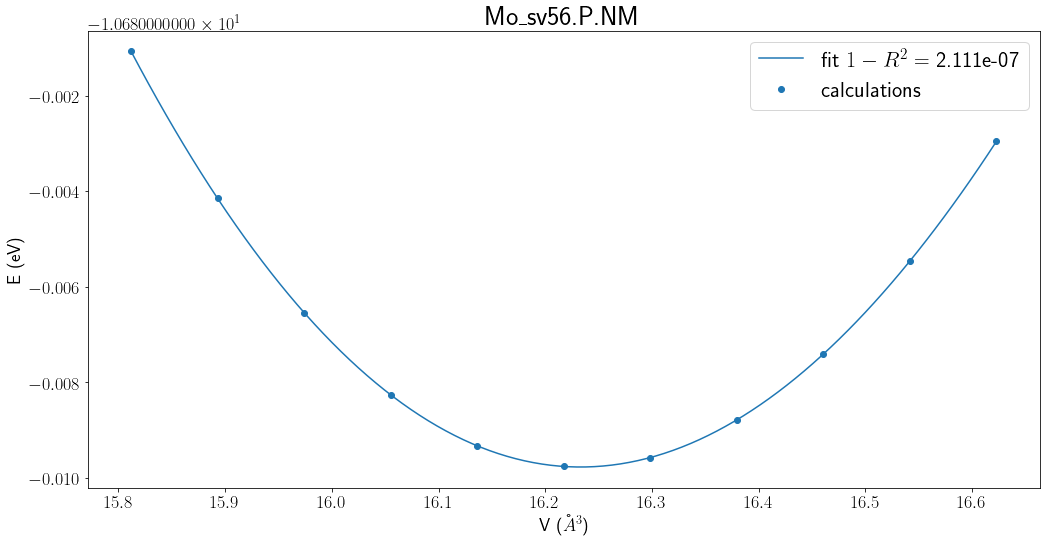

In [43]:
EVtools.plot_curves(EVcurves[test_indexes], Fits[test_indexes], R2[test_indexes])

In [46]:
EVcurves_df = pd.DataFrame.from_dict(EVcurves.to_dict(), orient='index')

In [47]:
R2_df = pd.DataFrame.from_dict(R2.to_dict(), orient='index')

In [48]:
Fits_df = pd.DataFrame.from_dict(Fits.to_dict(), orient='index')

In [49]:
Better_evcurves = {}

In [50]:
for index, evcurves in EVcurves_df.iterrows():
    nonan_evcurves = evcurves.dropna()
    if len(nonan_evcurves) > 1:
        break
    nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
    Better_evcurves[index] = nonan_evcurves[nonan_evcurves.index][0]

/tmp/ipykernel_359156/1452277664.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
/tmp/ipykernel_359156/1452277664.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Better_evcurves[index] = nonan_evcurves[nonan_evcurves.index][0]


In [54]:
Better_evcurves_df = pd.DataFrame.from_dict(Better_evcurves, orient='index')

In [55]:
ev_fit_results_df = pd.DataFrame.from_dict(Better_evcurves_df.ev_fit_results.to_dict(), orient='index')

In [56]:
fit_results = Better_evcurves_df.fit.map( lambda f : {name: val for name, val in zip(['E_murn', 'B_murn', 'Bdev_murn', 'V_murn'], f)})

In [57]:
fit_results_df = pd.DataFrame.from_dict(fit_results.to_dict(), orient='index')

Text(0.5, 1.0, '28 Good Samples')

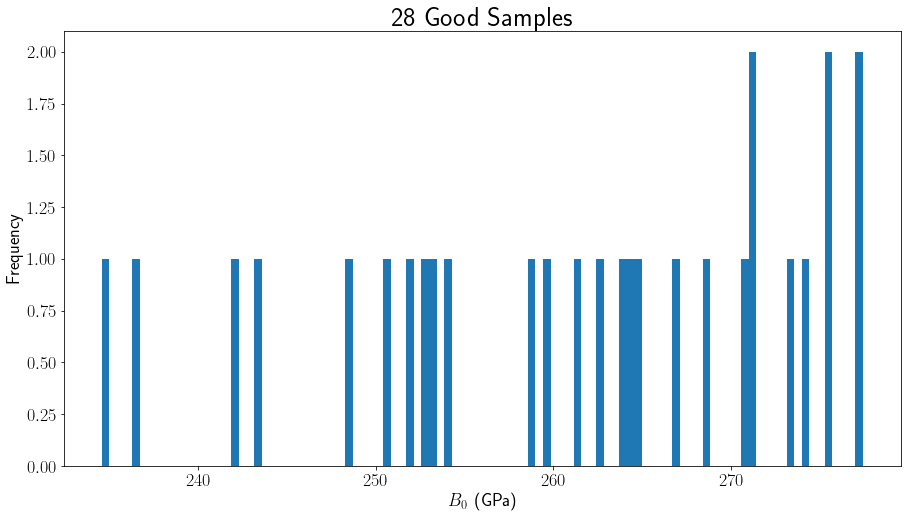

In [59]:
ax = fit_results_df[Better_evcurves_df.IsGood]['B_murn'].plot.hist(bins=100)
ax.set_xlabel(xlabel=r'$B_0$ (GPa)')
Ngood = Better_evcurves_df.IsGood.sum()
ax.set_title(f'{Ngood} Good Samples')

In [60]:
indexofgoodsamples = Better_evcurves_df.index[Better_evcurves_df.IsGood]

In [61]:
indexofbadsamples = Better_evcurves_df.index.difference(indexofgoodsamples) #[~Better_evcurves_df.IsGood]

In [62]:
indexofbadsamples

Index(['Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM',
       'Fe_pv16Mo_sv40.delta-BBBBBBBBABAABA.NM',
       'Fe_pv19Mo_sv34.R-ABABAABBBBB.NM', 'Fe_pv20Mo_sv33.R-BAAABABBBBB.NM',
       'Fe_pv24Mo_sv32.P-AAABBBBABBAB.NM', 'Fe_pv28Mo_sv24.M-AAAAABBBBBB.NM',
       'Fe_pv32Mo_sv20.M-AAAAAABBBBB.NM', 'Fe_pv32Mo_sv24.P-AAABBBAAABAB.NM',
       'Fe_pv32Mo_sv24.delta-BBBAABBBAAAAAA.NM',
       'Fe_pv36Mo_sv16.M-AAAAAAABBBB.NM', 'Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM',
       'Fe_pv40Mo_sv12.M-AAAAAAABABB.NM',
       'Fe_pv40Mo_sv16.delta-AAAAAABBABAAAB.NM',
       'Fe_pv44Mo_sv8.M-AAAAAAAAABB.NM', 'Fe_pv48Mo_sv4.M-AAAAAAAAAAB.NM',
       'Fe_pv48Mo_sv4.M-AAAAAAAAABA.NM',
       'Fe_pv48Mo_sv8.delta-AAAAAABAAAAABA.NM',
       'Fe_pv52Mo_sv4.P-AAAAABAAAAAA.NM', 'Fe_pv52Mo_sv4.P-AAAABAAAAAAA.NM',
       'Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM', 'Fe_pv56.P.NM',
       'Fe_pv56.delta.NM', 'Fe_pv6Mo_sv47.R-BBBBBABBBBB.NM',
       'Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM'],
      dtype='object')

In [63]:
Better_evcurves_df.index.difference(validationBS.index)

Index([], dtype='object')

Text(0.5, 1.0, '28 Good Samples')

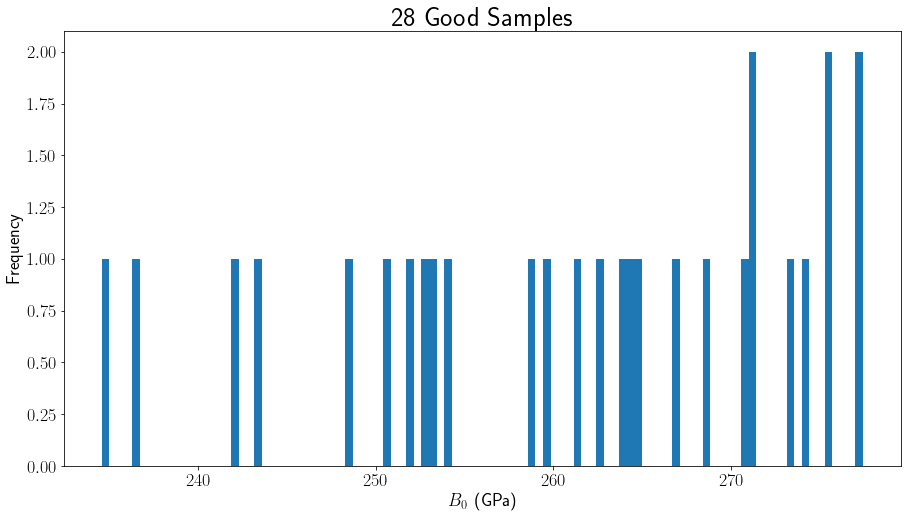

In [64]:
ax = fit_results_df[Better_evcurves_df.IsGood]['B_murn'].plot.hist(bins=100)
ax.set_xlabel(xlabel=r'$B_0$ (GPa)')
Ngood = Better_evcurves_df.IsGood.sum()
ax.set_title(f'{Ngood} Good Samples')

In [65]:
indexofgoodsamples = Better_evcurves_df.index[Better_evcurves_df.IsGood]

In [66]:
indexofbadsamples = Better_evcurves_df.index.difference(indexofgoodsamples) #[~Better_evcurves_df.IsGood]

In [68]:
Better_evcurves_df.index.difference(validationBS.index)

Index([], dtype='object')

In [69]:
hist, bins = np.histogram(1-Better_evcurves_df.r2[indexofgoodsamples], bins=100)
logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
fig, ax = plt.subplots()
ax.hist(1-Better_evcurves_df.r2[indexofgoodsamples], bins=logbins)
Better_evcurves_df.r2[indexofgoodsamples]
ax.set_xscale('log')
xlabel = ax.set_xlabel('$1-R^2$')
NGOOD = len(indexofgoodsamples)
ax.legend(title=f'{NGOOD} good samples')

NameError: name 'np' is not defined

# Differences between fits and available data for bad samples

In [80]:
import matplotlib.pyplot as plt
import numpy as np

In [81]:
diff_fit_to_dataset = ((validationBS.B0[indexofbadsamples] - fit_results_df.B_murn[indexofbadsamples])/fit_results_df.B_murn[indexofbadsamples]).abs().to_frame().rename(columns={0: 'B0'})

In [82]:
diff_fit_to_dataset['E0'] = ((validationBS.E0[indexofbadsamples] - fit_results_df.E_murn[indexofbadsamples])/fit_results_df.E_murn[indexofbadsamples]).abs().dropna()

In [83]:
diff_fit_to_dataset['V0'] = ((validationBS.V0[indexofbadsamples] - fit_results_df.V_murn[indexofbadsamples])/fit_results_df.V_murn[indexofbadsamples]).abs().dropna()

Text(0.5, 0, '$|(E_0 ^{fit} - E_0 ^{BS})/E_0^{BS}|$')

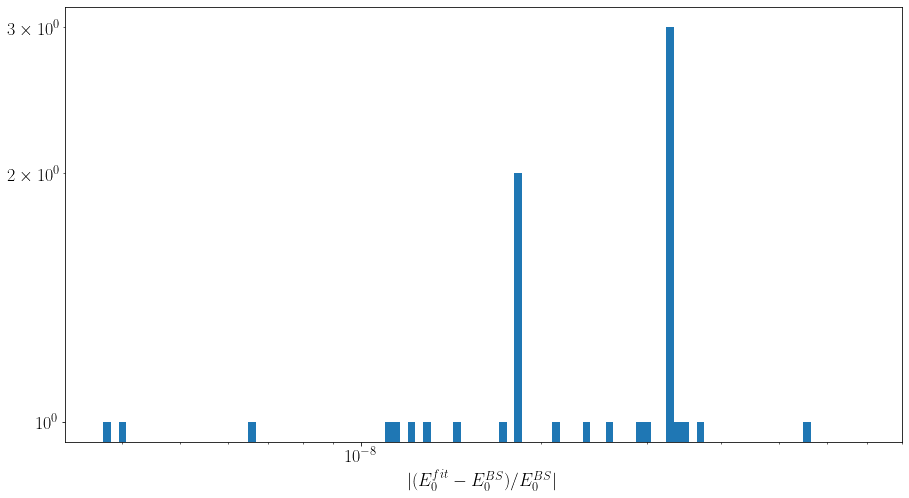

In [84]:
large_diff_E0 = diff_fit_to_dataset.query('E0 > 1e-5').index
fig, ax = plt.subplots()
hist, bins = np.histogram(diff_fit_to_dataset.E0, bins=100)
logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
loghist = plt.hist(diff_fit_to_dataset.E0, bins=logbins)
fig = plt.xscale('log')
fig = plt.yscale('log')
for index in large_diff_E0:
    x = diff_fit_to_dataset.E0[index]
    y = 1
    ax.annotate(index, (x, y), rotation='90')
plt.xlabel(r'$|(E_0 ^{fit} - E_0 ^{BS})/E_0^{BS}|$')